In [ ]:
import os
import sys
import math
import time
import json
import shutil
import subprocess
import textwrap
import warnings

warnings.filterwarnings("ignore")

def run_cmd(cmd, check=False, capture=True):
    print(f"\n$ {cmd}")
    result = subprocess.run(
        cmd,
        shell=True,
        text=True,
        capture_output=capture
    )
    if capture:
        if result.stdout.strip():
            print(result.stdout.strip())
        if result.stderr.strip():
            print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")
    return result

print("=" * 90)
print("cuTile Python Advanced Colab Tutorial")
print("=" * 90)

print("\n[1] Installing Python dependencies")
run_cmd(f"{sys.executable} -m pip install -q -U pip setuptools wheel", check=False)
run_cmd(f"{sys.executable} -m pip install -q -U torch numpy pandas matplotlib", check=False)

print("\n[2] Trying to install cuTile Python")
print("Package name on PyPI: cuda-tile[tileiras]")
install_result = run_cmd(
    f'{sys.executable} -m pip install -q -U "cuda-tile[tileiras]"',
    check=False
)

print("\n[3] Runtime and GPU diagnostics")
run_cmd("python --version", check=False)
run_cmd("nvidia-smi", check=False)

try:
    import torch
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError(f"Core dependency import failed: {e}")

cuda_available = torch.cuda.is_available()
print(f"\nPyTorch CUDA available: {cuda_available}")

if cuda_available:
    device_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    print(f"GPU: {device_name}")
    print(f"Compute capability: sm_{capability[0]}{capability[1]}")
else:
    print("No CUDA GPU detected. Colab: Runtime -> Change runtime type -> GPU")

def parse_driver_major():
    try:
        out = subprocess.check_output(
            "nvidia-smi --query-gpu=driver_version --format=csv,noheader",
            shell=True,
            text=True
        ).strip().splitlines()[0]
        return int(out.split(".")[0]), out
    except Exception:
        return None, None

driver_major, driver_full = parse_driver_major()
print(f"NVIDIA driver version: {driver_full}")

ct = None
cutile_import_ok = False

try:
    import cuda.tile as ct
    cutile_import_ok = True
    print("cuda.tile import: OK")
except Exception as e:
    print("cuda.tile import: FAILED")
    print(str(e))

likely_runtime_ok = (
    cuda_available
    and cutile_import_ok
    and driver_major is not None
    and driver_major >= 580
)

if likely_runtime_ok:
    print("\ncuTile path is enabled.")
else:
    print("\ncuTile path is not enabled in this runtime.")
    print("The tutorial will still run using a PyTorch fallback.")
    print("For real cuTile execution, use a runtime with NVIDIA Driver R580+ and CUDA Toolkit 13.1+.")

DEVICE = "cuda" if cuda_available else "cpu"

In [ ]:
print("\n" + "=" * 90)
print("[4] Utilities: timing, correctness checks, and compact reporting")
print("=" * 90)

def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def benchmark(fn, warmup=5, repeat=20, label="function"):
    for _ in range(warmup):
        fn()
    sync()
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        out = fn()
        sync()
        end = time.perf_counter()
        times.append((end - start) * 1000)
    return {
        "label": label,
        "mean_ms": float(np.mean(times)),
        "median_ms": float(np.median(times)),
        "min_ms": float(np.min(times)),
        "max_ms": float(np.max(times)),
    }

def show_result_table(rows, title):
    df = pd.DataFrame(rows)
    print("\n" + title)
    print(df.to_string(index=False))
    return df

def assert_close(name, actual, expected, atol=1e-4, rtol=1e-4):
    torch.testing.assert_close(actual, expected, atol=atol, rtol=rtol)
    print(f"{name}: correctness check passed")

In [ ]:
print("\n" + "=" * 90)
print("[5] cuTile kernels are defined only if cuda.tile imports successfully")
print("=" * 90)

if cutile_import_ok:
    ConstInt = ct.Constant[int]

    @ct.kernel
    def cutile_vec_add_direct_kernel(a, b, c, TILE: ConstInt):
        bid = ct.bid(0)
        a_tile = ct.load(a, index=(bid,), shape=(TILE,))
        b_tile = ct.load(b, index=(bid,), shape=(TILE,))
        c_tile = a_tile + b_tile
        ct.store(c, index=(bid,), tile=c_tile)

    @ct.kernel
    def cutile_vec_add_gather_kernel(a, b, c, TILE: ConstInt):
        bid = ct.bid(0)
        offsets = bid * TILE + ct.arange(TILE, dtype=torch.int32)
        a_tile = ct.gather(a, offsets)
        b_tile = ct.gather(b, offsets)
        c_tile = a_tile + b_tile
        ct.scatter(c, offsets, c_tile)

    @ct.kernel
    def cutile_matrix_add_gather_kernel(a, b, c, TILE_M: ConstInt, TILE_N: ConstInt):
        bid_m = ct.bid(0)
        bid_n = ct.bid(1)

        rows = bid_m * TILE_M + ct.arange(TILE_M, dtype=torch.int32)
        cols = bid_n * TILE_N + ct.arange(TILE_N, dtype=torch.int32)

        rows = rows[:, None]
        cols = cols[None, :]

        a_tile = ct.gather(a, (rows, cols))
        b_tile = ct.gather(b, (rows, cols))
        c_tile = a_tile + b_tile

        ct.scatter(c, (rows, cols), c_tile)

    @ct.kernel
    def cutile_matmul_kernel(A, B, C, TM: ConstInt, TN: ConstInt, TK: ConstInt):
        bid_m = ct.bid(0)
        bid_n = ct.bid(1)

        num_tiles_k = ct.num_tiles(A, axis=1, shape=(TM, TK))
        acc = ct.full((TM, TN), 0, dtype=ct.float32)

        zero_pad = ct.PaddingMode.ZERO
        compute_dtype = ct.tfloat32 if A.dtype == ct.float32 else A.dtype

        for k in range(num_tiles_k):
            a_tile = ct.load(
                A,
                index=(bid_m, k),
                shape=(TM, TK),
                padding_mode=zero_pad
            ).astype(compute_dtype)

            b_tile = ct.load(
                B,
                index=(k, bid_n),
                shape=(TK, TN),
                padding_mode=zero_pad
            ).astype(compute_dtype)

            acc = ct.mma(a_tile, b_tile, acc)

        out = ct.astype(acc, C.dtype)
        ct.store(C, index=(bid_m, bid_n), tile=out)

else:
    print("Skipping cuTile kernel definitions because cuda.tile is unavailable.")

print("\n" + "=" * 90)
print("[6] High-level wrappers")
print("=" * 90)

def vec_add_tutorial(a, b, use_gather=True):
    if a.shape != b.shape:
        raise ValueError("a and b must have the same shape")

    if likely_runtime_ok and a.is_cuda:
        c = torch.empty_like(a)
        TILE = 256 if use_gather else min(1024, 2 ** math.ceil(math.log2(a.numel())))
        grid = (math.ceil(a.numel() / TILE), 1, 1)
        kernel = cutile_vec_add_gather_kernel if use_gather else cutile_vec_add_direct_kernel
        ct.launch(torch.cuda.current_stream(), grid, kernel, (a, b, c, TILE))
        return c

    return a + b

def matrix_add_tutorial(a, b):
    if a.shape != b.shape:
        raise ValueError("a and b must have the same shape")

    if likely_runtime_ok and a.is_cuda:
        c = torch.empty_like(a)
        TILE_M = 16
        TILE_N = 64
        grid = (math.ceil(a.shape[0] / TILE_M), math.ceil(a.shape[1] / TILE_N), 1)
        ct.launch(
            torch.cuda.current_stream(),
            grid,
            cutile_matrix_add_gather_kernel,
            (a, b, c, TILE_M, TILE_N)
        )
        return c

    return a + b

def matmul_tutorial(A, B):
    if A.shape[1] != B.shape[0]:
        raise ValueError("A.shape[1] must equal B.shape[0]")

    if likely_runtime_ok and A.is_cuda:
        if A.dtype in (torch.float16, torch.bfloat16):
            TM, TN, TK = 128, 128, 64
        else:
            TM, TN, TK = 32, 32, 32

        C = torch.empty((A.shape[0], B.shape[1]), device=A.device, dtype=A.dtype)
        grid = (math.ceil(A.shape[0] / TM), math.ceil(B.shape[1] / TN), 1)

        ct.launch(
            torch.cuda.current_stream(),
            grid,
            cutile_matmul_kernel,
            (A, B, C, TM, TN, TK)
        )
        return C

    return A @ B

print("Wrappers ready.")
print(f"Execution backend: {'cuTile' if likely_runtime_ok else 'PyTorch fallback'}")

In [ ]:
print("\n" + "=" * 90)
print("[7] Example 1: tiled vector addition")
print("=" * 90)

torch.manual_seed(42)

N = 1_000_003
a = torch.randn(N, device=DEVICE, dtype=torch.float32)
b = torch.randn(N, device=DEVICE, dtype=torch.float32)

c = vec_add_tutorial(a, b, use_gather=True)
expected = a + b

assert_close("Vector addition", c, expected)

print(f"Input shape: {tuple(a.shape)}")
print(f"Output shape: {tuple(c.shape)}")
print(f"First five output values: {c[:5].detach().cpu().numpy()}")

print("\n" + "=" * 90)
print("[8] Example 2: tiled matrix addition with boundary-safe gather/scatter")
print("=" * 90)

M, N = 777, 1001
A = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
B = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

C = matrix_add_tutorial(A, B)
expected = A + B

assert_close("Matrix addition", C, expected)

print(f"A shape: {tuple(A.shape)}")
print(f"B shape: {tuple(B.shape)}")
print(f"C shape: {tuple(C.shape)}")

print("\n" + "=" * 90)
print("[9] Example 3: tiled matrix multiplication")
print("=" * 90)

M, K, N = 512, 768, 384
A32 = torch.randn(M, K, device=DEVICE, dtype=torch.float32)
B32 = torch.randn(K, N, device=DEVICE, dtype=torch.float32)

if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")

C32 = matmul_tutorial(A32, B32)
expected32 = A32 @ B32

if DEVICE == "cuda":
    atol, rtol = 1e-2, 1e-2
else:
    atol, rtol = 1e-4, 1e-4

assert_close("Float32 matmul", C32, expected32, atol=atol, rtol=rtol)

print(f"A32 shape: {tuple(A32.shape)}")
print(f"B32 shape: {tuple(B32.shape)}")
print(f"C32 shape: {tuple(C32.shape)}")

print("\n" + "=" * 90)
print("[10] Example 4: half precision matmul")
print("=" * 90)

if DEVICE == "cuda":
    A16 = torch.randn(M, K, device=DEVICE, dtype=torch.float16)
    B16 = torch.randn(K, N, device=DEVICE, dtype=torch.float16)

    C16 = matmul_tutorial(A16, B16)
    expected16 = A16 @ B16

    assert_close("Float16 matmul", C16, expected16, atol=5e-2, rtol=5e-2)

    print(f"A16 shape: {tuple(A16.shape)}")
    print(f"B16 shape: {tuple(B16.shape)}")
    print(f"C16 shape: {tuple(C16.shape)}")
else:
    print("Skipping float16 GPU matmul because CUDA is unavailable.")

cuTile Python Advanced Colab Tutorial

[1] Installing Python dependencies

$ /usr/bin/python3 -m pip install -q -U pip setuptools wheel
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.

$ /usr/bin/python3 -m pip install -q -U torch numpy pandas matplotlib
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is 

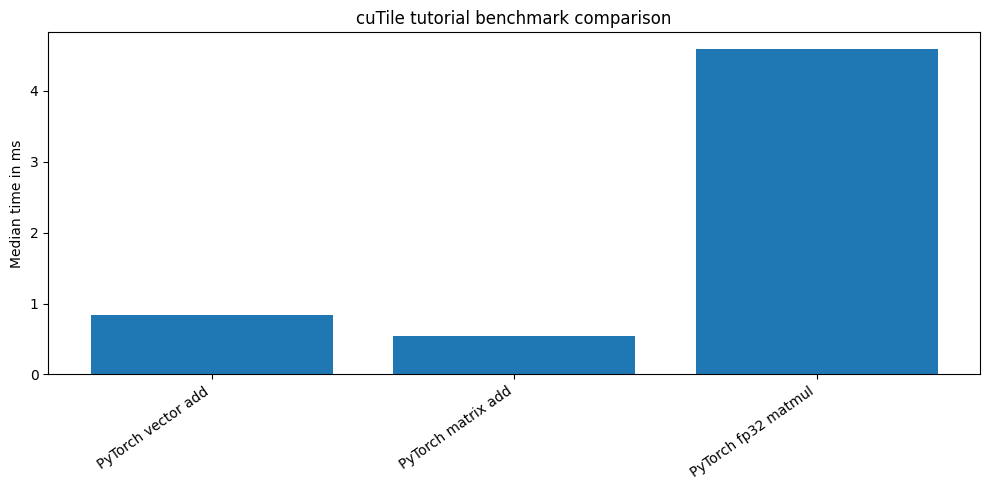


[13] What to change next
             experiment                               what_to_change                                                        why_it_matters
        Tile size sweep  Change TILE, TILE_M, TILE_N, TM, TN, and TK   Tile shape controls memory access, occupancy, and Tensor Core usage
Non-multiple dimensions               Use dimensions like 1003 x 771                  Tests padding, gather/scatter, and boundary behavior
   Precision comparison       Compare float32, float16, and bfloat16                 Tensor Core paths are strongest for reduced precision
       Operation fusion Extend vector add to compute c = relu(a + b) Fusion reduces memory traffic and is a common GPU-kernel optimization
 Attention kernel study     Study the repo's AttentionFMHA.py sample    Attention shows why tiled kernels matter for transformer workloads

Tutorial completed.
This runtime used the PyTorch fallback.
To run real cuTile kernels, use a GPU machine with NVIDIA Driver R580+ and CUDA

In [2]:
print("\n" + "=" * 90)
print("[11] Benchmarks")
print("=" * 90)

bench_rows = []

bench_rows.append(
    benchmark(
        lambda: vec_add_tutorial(a, b, use_gather=True),
        label=f"{'cuTile' if likely_runtime_ok else 'PyTorch'} vector add"
    )
)

bench_rows.append(
    benchmark(
        lambda: a + b,
        label="PyTorch vector add"
    )
)

bench_rows.append(
    benchmark(
        lambda: matrix_add_tutorial(A, B),
        label=f"{'cuTile' if likely_runtime_ok else 'PyTorch'} matrix add"
    )
)

bench_rows.append(
    benchmark(
        lambda: A + B,
        label="PyTorch matrix add"
    )
)

bench_rows.append(
    benchmark(
        lambda: matmul_tutorial(A32, B32),
        label=f"{'cuTile' if likely_runtime_ok else 'PyTorch'} fp32 matmul"
    )
)

bench_rows.append(
    benchmark(
        lambda: A32 @ B32,
        label="PyTorch fp32 matmul"
    )
)

bench_df = show_result_table(bench_rows, "Benchmark summary in milliseconds")

print("\n" + "=" * 90)
print("[12] Simple benchmark visualization")
print("=" * 90)

try:
    plt.figure(figsize=(10, 5))
    plt.bar(bench_df["label"], bench_df["median_ms"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Median time in ms")
    plt.title("cuTile tutorial benchmark comparison")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot skipped: {e}")

print("\n" + "=" * 90)
print("[13] What to change next")
print("=" * 90)

next_steps = [
    {
        "experiment": "Tile size sweep",
        "what_to_change": "Change TILE, TILE_M, TILE_N, TM, TN, and TK",
        "why_it_matters": "Tile shape controls memory access, occupancy, and Tensor Core usage"
    },
    {
        "experiment": "Non-multiple dimensions",
        "what_to_change": "Use dimensions like 1003 x 771",
        "why_it_matters": "Tests padding, gather/scatter, and boundary behavior"
    },
    {
        "experiment": "Precision comparison",
        "what_to_change": "Compare float32, float16, and bfloat16",
        "why_it_matters": "Tensor Core paths are strongest for reduced precision"
    },
    {
        "experiment": "Operation fusion",
        "what_to_change": "Extend vector add to compute c = relu(a + b)",
        "why_it_matters": "Fusion reduces memory traffic and is a common GPU-kernel optimization"
    },
    {
        "experiment": "Attention kernel study",
        "what_to_change": "Study the repo's AttentionFMHA.py sample",
        "why_it_matters": "Attention shows why tiled kernels matter for transformer workloads"
    }
]

next_df = pd.DataFrame(next_steps)
print(next_df.to_string(index=False))

print("\n" + "=" * 90)
print("Tutorial completed.")
print("=" * 90)

if likely_runtime_ok:
    print("Real cuTile kernels were used.")
else:
    print("This runtime used the PyTorch fallback.")
    print("To run real cuTile kernels, use a GPU machine with NVIDIA Driver R580+ and CUDA Toolkit 13.1+.")